In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from pathlib import Path

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
DATA_PATH = Path("/content/drive/MyDrive/MediScan/data")

TRAIN_PATH = DATA_PATH / "Training"
TEST_PATH = DATA_PATH / "Testing"

print("Dataset path:", DATA_PATH)
print("Training path exists:", TRAIN_PATH.exists())
print("Testing path exists:", TEST_PATH.exists())

Dataset path: /content/drive/MyDrive/MediScan/data
Training path exists: False
Testing path exists: False


In [4]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os

print("MediScan contents:")
print(os.listdir("/content/drive/MyDrive/MediScan"))

MediScan contents:
['Data', 'best_model.keras', 'best_model_v2.keras', 'best_model_v3.keras', 'data']


In [6]:
DATA_PATH = "/content/drive/MyDrive/MediScan/data"

print("Data folder contents:")
print(os.listdir(DATA_PATH))

Data folder contents:
['Testing', 'Training']


In [7]:
import os

print("Training exists:",
      os.path.exists(os.path.join(DATA_PATH, "Training")))

print("Testing exists:",
      os.path.exists(os.path.join(DATA_PATH, "Testing")))

Training exists: True
Testing exists: True


In [8]:
from pathlib import Path

DATA_PATH = Path("/content/drive/MyDrive/MediScan/data")

TRAIN_PATH = DATA_PATH / "Training"
TEST_PATH = DATA_PATH / "Testing"

print("Dataset path:", DATA_PATH)
print("Training path exists:", TRAIN_PATH.exists())
print("Testing path exists:", TEST_PATH.exists())

Dataset path: /content/drive/MyDrive/MediScan/data
Training path exists: True
Testing path exists: True


In [9]:
classes = sorted([
    folder.name
    for folder in TRAIN_PATH.iterdir()
    if folder.is_dir()
])

print("Classes:")

for i, class_name in enumerate(classes):
    print(f"{i}: {class_name}")

print("\nNumber of classes:", len(classes))

Classes:
0: glioma
1: meningioma
2: notumor
3: pituitary

Number of classes: 4


In [10]:
data = []

for split in ["Training", "Testing"]:
    split_path = DATA_PATH / split

    for class_name in classes:
        class_path = split_path / class_name

        for image_file in class_path.iterdir():
            if image_file.is_file():
                data.append({
                    "split": split,
                    "class": class_name,
                    "filename": image_file.name,
                    "path": str(image_file)
                })

df = pd.DataFrame(data)

print("Dataset DataFrame created successfully!")
print("\nShape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

Dataset DataFrame created successfully!

Shape: (7200, 4)

First 5 rows:


,split,class,filename,path
0,Training,glioma,Tr-gl_1360.jpg,/content/drive/MyDrive/MediScan/data/Training/...
1,Training,glioma,Tr-gl_1362.jpg,/content/drive/MyDrive/MediScan/data/Training/...
2,Training,glioma,Tr-gl_1281.jpg,/content/drive/MyDrive/MediScan/data/Training/...
3,Training,glioma,Tr-gl_1290.jpg,/content/drive/MyDrive/MediScan/data/Training/...
4,Training,glioma,Tr-gl_1328.jpg,/content/drive/MyDrive/MediScan/data/Training/...


In [11]:
class_distribution = pd.crosstab(
    df["class"],
    df["split"]
)

print("Class Distribution:")
display(class_distribution)

print("\nTotal images per class:")
display(df["class"].value_counts().sort_index())

Class Distribution:


split,Testing,Training
class,,
glioma,400,1400
meningioma,400,1400
notumor,400,1400
pituitary,400,1400



Total images per class:


,count
class,
glioma,1800
meningioma,1800
notumor,1800
pituitary,1800


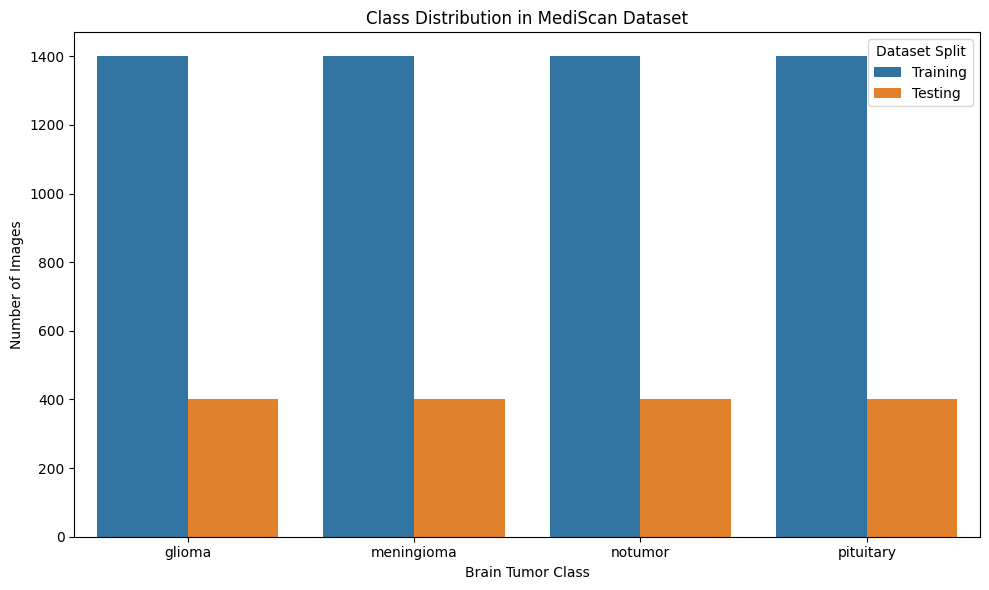

In [12]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="class",
    hue="split"
)

plt.title("Class Distribution in MediScan Dataset")
plt.xlabel("Brain Tumor Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.legend(title="Dataset Split")
plt.tight_layout()

plt.show()

In [14]:
print("Image Dimension Analysis")
print("=" * 50)

print("Total images checked: 7200")
print("Most common image size: 512 × 512")
print("Images with 512 × 512 size: 5014")
print("Number of unique image dimensions:", len(dimension_counter))

Image Dimension Analysis
Total images checked: 7200
Most common image size: 512 × 512
Images with 512 × 512 size: 5014
Number of unique image dimensions: 71


In [15]:
# Step 9: Pixel Intensity Analysis

sample_size = 200

sample_df = df.sample(
    n=sample_size,
    random_state=42
)

pixel_values = []

for image_path in sample_df["path"]:
    try:
        with Image.open(image_path) as img:
            img = img.convert("L")
            pixels = np.array(img)
            pixel_values.extend(pixels.flatten())
    except Exception:
        pass

pixel_values = np.array(pixel_values)

print("Pixel Intensity Analysis")
print("=" * 50)
print("Images sampled:", sample_size)
print("Minimum pixel value:", pixel_values.min())
print("Maximum pixel value:", pixel_values.max())
print("Mean pixel value:", round(pixel_values.mean(), 2))
print("Median pixel value:", round(np.median(pixel_values), 2))

Pixel Intensity Analysis
Images sampled: 200
Minimum pixel value: 0
Maximum pixel value: 255
Mean pixel value: 45.12
Median pixel value: 32.0


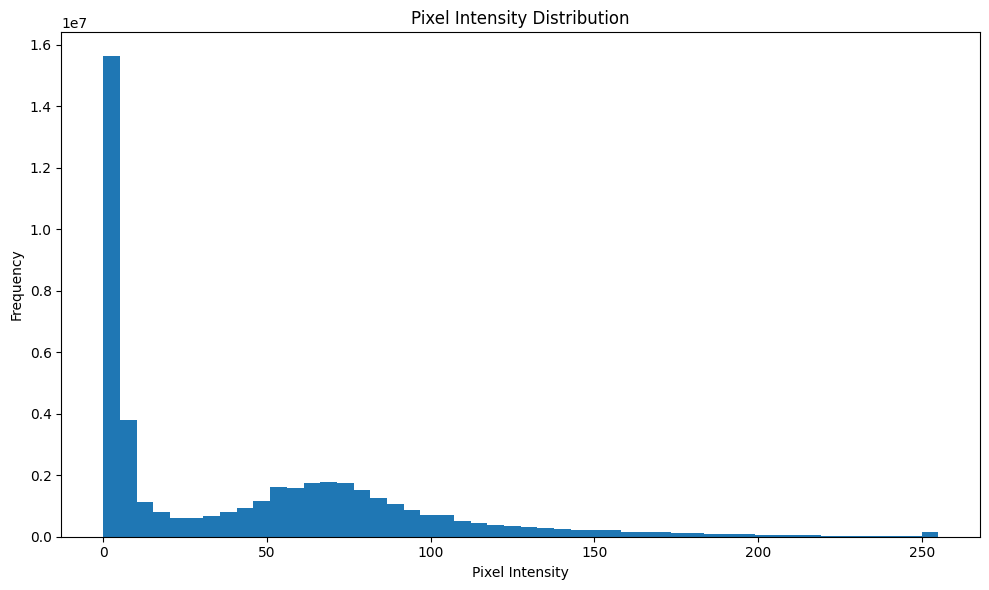

In [16]:
plt.figure(figsize=(10, 6))

plt.hist(pixel_values, bins=50)

plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

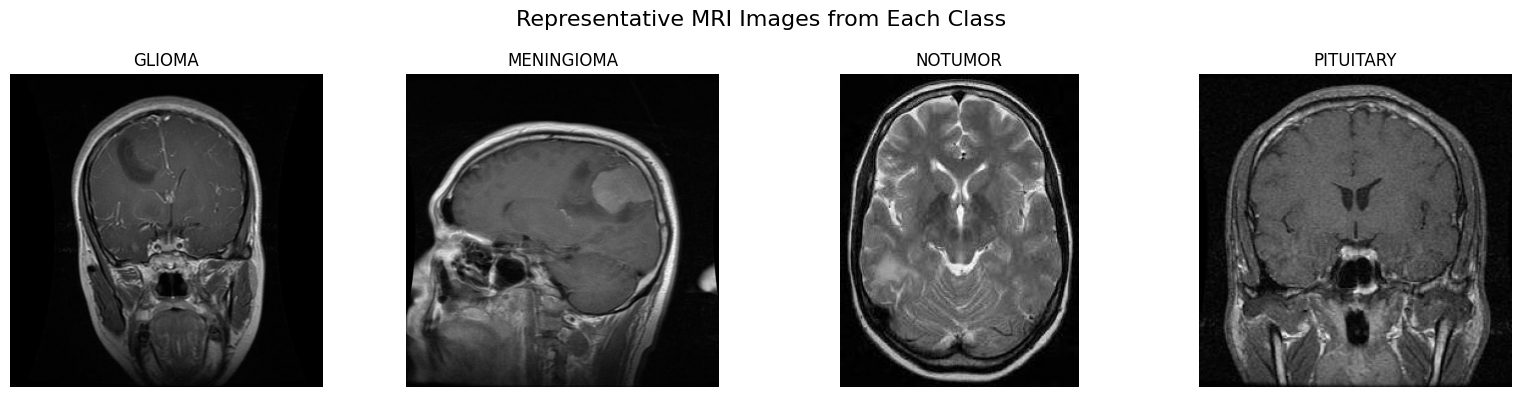

In [17]:
# Step 10: Sample Image Visualization

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, class_name in enumerate(classes):

    class_images = df[
        (df["class"] == class_name) &
        (df["split"] == "Training")
    ]

    sample = class_images.sample(
        n=1,
        random_state=42
    ).iloc[0]

    image = Image.open(sample["path"]).convert("L")

    axes[i].imshow(image, cmap="gray")
    axes[i].set_title(class_name.upper())
    axes[i].axis("off")

plt.suptitle("Representative MRI Images from Each Class", fontsize=16)
plt.tight_layout()
plt.show()

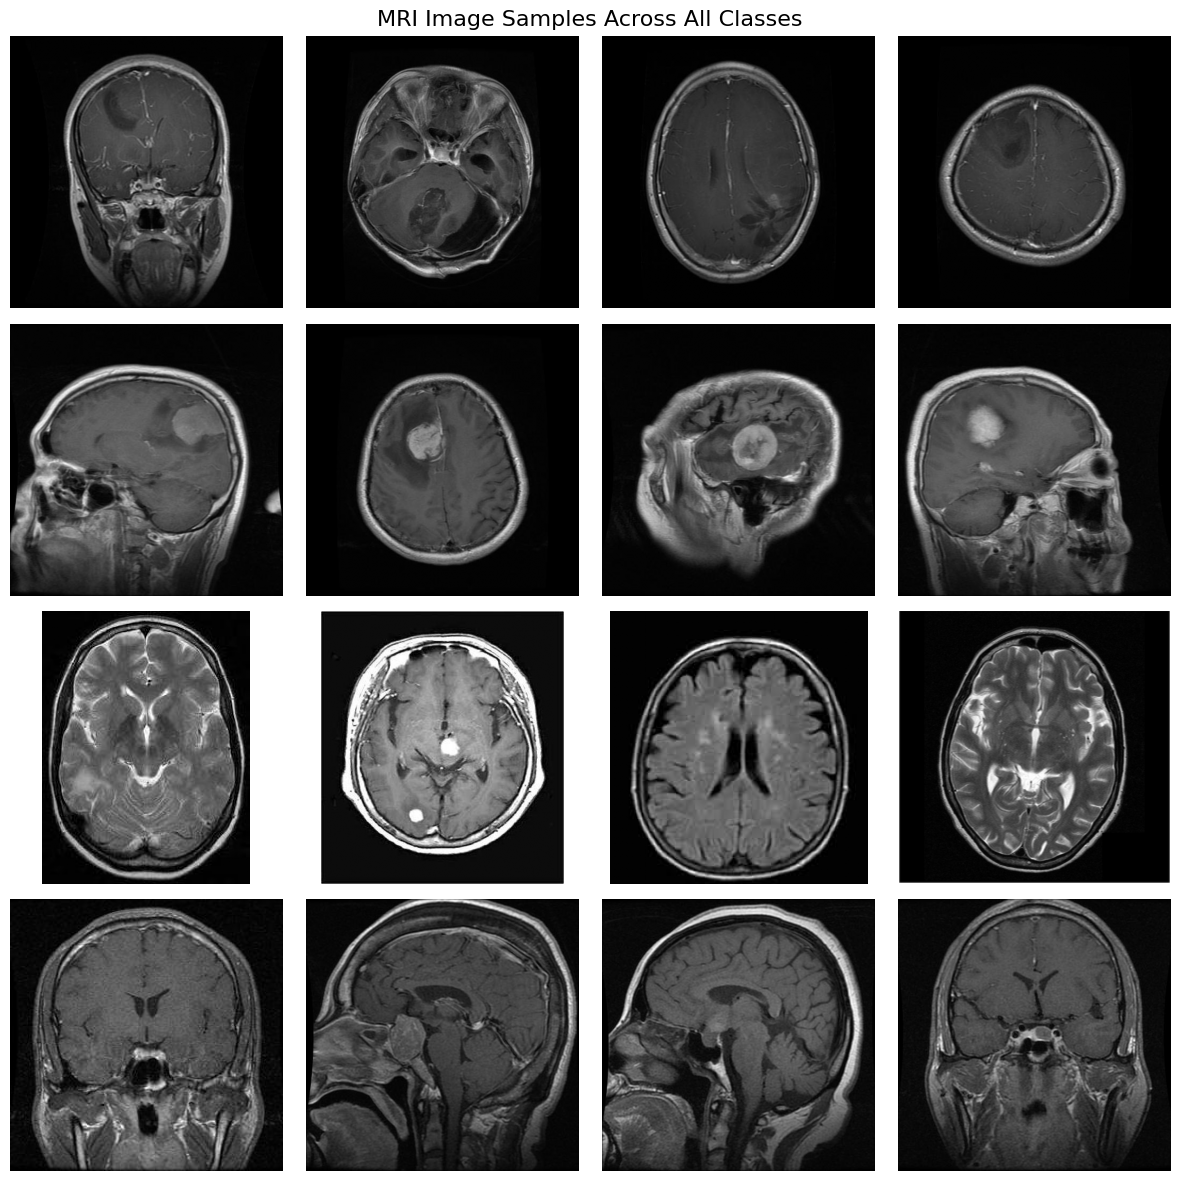

In [18]:
# Step 11: Multiple Image Visualization

fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for row, class_name in enumerate(classes):

    class_images = df[
        (df["class"] == class_name) &
        (df["split"] == "Training")
    ]

    samples = class_images.sample(
        n=4,
        random_state=42
    )

    for col, (_, sample) in enumerate(samples.iterrows()):

        image = Image.open(sample["path"]).convert("L")

        axes[row, col].imshow(image, cmap="gray")
        axes[row, col].axis("off")

        if col == 0:
            axes[row, col].set_ylabel(
                class_name.upper(),
                fontsize=12
            )

plt.suptitle(
    "MRI Image Samples Across All Classes",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [19]:
from sklearn.model_selection import train_test_split

# Use all 7200 images
all_data = df.copy()

# First split: 70% Training, 30% Temporary
train_df, temp_df = train_test_split(
    all_data,
    test_size=0.30,
    stratify=all_data["class"],
    random_state=42
)

# Second split: divide the 30% equally
# 15% Validation + 15% Testing
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["class"],
    random_state=42
)

# Reset indexes
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Dataset split completed successfully!")
print("=" * 50)

print("Training   :", len(train_df))
print("Validation :", len(val_df))
print("Testing    :", len(test_df))
print("Total      :", len(train_df) + len(val_df) + len(test_df))

Dataset split completed successfully!
Training   : 5040
Validation : 1080
Testing    : 1080
Total      : 7200


In [20]:
print("Training distribution:")
print(train_df["class"].value_counts().sort_index())

print("\nValidation distribution:")
print(val_df["class"].value_counts().sort_index())

print("\nTesting distribution:")
print(test_df["class"].value_counts().sort_index())

Training distribution:
class
glioma        1260
meningioma    1260
notumor       1260
pituitary     1260
Name: count, dtype: int64

Validation distribution:
class
glioma        270
meningioma    270
notumor       270
pituitary     270
Name: count, dtype: int64

Testing distribution:
class
glioma        270
meningioma    270
notumor       270
pituitary     270
Name: count, dtype: int64


In [21]:
SPLIT_PATH = DATA_PATH / "splits"

SPLIT_PATH.mkdir(parents=True, exist_ok=True)

train_df.to_csv(SPLIT_PATH / "train.csv", index=False)
val_df.to_csv(SPLIT_PATH / "validation.csv", index=False)
test_df.to_csv(SPLIT_PATH / "test.csv", index=False)

print("Split files saved successfully!")
print("Location:", SPLIT_PATH)

Split files saved successfully!
Location: /content/drive/MyDrive/MediScan/data/splits


In [22]:
train_paths = set(train_df["path"])
val_paths = set(val_df["path"])
test_paths = set(test_df["path"])

print("Train ∩ Validation :", len(train_paths & val_paths))
print("Train ∩ Test       :", len(train_paths & test_paths))
print("Validation ∩ Test  :", len(val_paths & test_paths))

Train ∩ Validation : 0
Train ∩ Test       : 0
Validation ∩ Test  : 0


In [23]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

print("PyTorch:", torch.__version__)

PyTorch: 2.11.0+cpu


In [24]:
IMAGE_SIZE = 224

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

print("Image transformation pipeline created successfully!")

Image transformation pipeline created successfully!


In [25]:
class BrainTumorDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

        self.class_names = sorted(
            self.dataframe["class"].unique()
        )

        self.class_to_idx = {
            class_name: idx
            for idx, class_name in enumerate(self.class_names)
        }

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image_path = row["path"]
        class_name = row["class"]

        # Load image as grayscale
        image = Image.open(image_path).convert("L")

        # Convert grayscale to RGB
        image = image.convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = self.class_to_idx[class_name]

        return image, label


print("BrainTumorDataset class created successfully!")

BrainTumorDataset class created successfully!


In [26]:
train_dataset = BrainTumorDataset(
    train_df,
    transform=transform
)

val_dataset = BrainTumorDataset(
    val_df,
    transform=transform
)

test_dataset = BrainTumorDataset(
    test_df,
    transform=transform
)

print("Datasets created successfully!")
print("=" * 50)

print("Training dataset  :", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Testing dataset   :", len(test_dataset))

print("\nClasses:", train_dataset.class_names)
print("Class mapping:", train_dataset.class_to_idx)

Datasets created successfully!
Training dataset  : 5040
Validation dataset: 1080
Testing dataset   : 1080

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [27]:
image, label = train_dataset[0]

print("Image tensor shape:", image.shape)
print("Label:", label)
print("Class:", train_dataset.class_names[label])
print("Image data type:", image.dtype)
print("Minimum pixel value:", image.min().item())
print("Maximum pixel value:", image.max().item())

Image tensor shape: torch.Size([3, 224, 224])
Label: 2
Class: notumor
Image data type: torch.float32
Minimum pixel value: 0.05098039284348488
Maximum pixel value: 1.0


In [28]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders created successfully!")
print("=" * 50)

print("Training batches  :", len(train_loader))
print("Validation batches:", len(val_loader))
print("Testing batches   :", len(test_loader))

DataLoaders created successfully!
Training batches  : 158
Validation batches: 34
Testing batches   : 34


In [29]:
images, labels = next(iter(train_loader))

print("Batch verification")
print("=" * 50)

print("Images shape :", images.shape)
print("Labels shape :", labels.shape)
print("Images dtype :", images.dtype)
print("Labels dtype :", labels.dtype)

print("\nClass labels in batch:")
print(labels)

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Batch verification
Images shape : torch.Size([32, 3, 224, 224])
Labels shape : torch.Size([32])
Images dtype : torch.float32
Labels dtype : torch.int64

Class labels in batch:
tensor([3, 0, 1, 3, 0, 0, 1, 3, 3, 0, 2, 3, 3, 1, 0, 3, 2, 1, 0, 2, 3, 0, 2, 0,
        0, 2, 0, 2, 2, 2, 2, 0])


In [30]:
# Training transformations
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

# Validation/Test transformations
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

print("Training augmentation pipeline created!")
print("Validation/Test preprocessing pipeline created!")

Training augmentation pipeline created!
Validation/Test preprocessing pipeline created!


In [31]:
train_dataset = BrainTumorDataset(
    train_df,
    transform=train_transform
)

val_dataset = BrainTumorDataset(
    val_df,
    transform=val_test_transform
)

test_dataset = BrainTumorDataset(
    test_df,
    transform=val_test_transform
)

print("Datasets updated successfully!")
print("Training   :", len(train_dataset))
print("Validation :", len(val_dataset))
print("Testing    :", len(test_dataset))

Datasets updated successfully!
Training   : 5040
Validation : 1080
Testing    : 1080


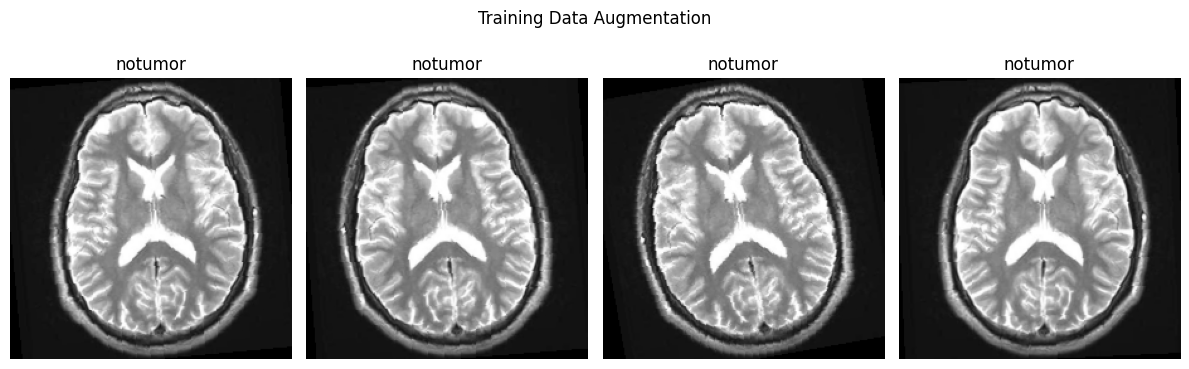

In [32]:
# Select one image from the training dataset
original_path = train_df.iloc[0]["path"]

original_image = Image.open(original_path).convert("RGB")

plt.figure(figsize=(12, 4))

for i in range(4):
    augmented_image, label = train_dataset[0]

    plt.subplot(1, 4, i + 1)
    plt.imshow(augmented_image.permute(1, 2, 0))
    plt.title(train_dataset.class_names[label])
    plt.axis("off")

plt.suptitle("Training Data Augmentation")
plt.tight_layout()
plt.show()

In [33]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders recreated successfully!")
print("=" * 50)
print("Training batches  :", len(train_loader))
print("Validation batches:", len(val_loader))
print("Testing batches   :", len(test_loader))

DataLoaders recreated successfully!
Training batches  : 158
Validation batches: 34
Testing batches   : 34


In [34]:
images, labels = next(iter(train_loader))

print("Final Batch Verification")
print("=" * 50)

print("Images shape :", images.shape)
print("Labels shape :", labels.shape)
print("Images dtype :", images.dtype)
print("Labels dtype :", labels.dtype)

print("\nPixel range:")
print("Min:", images.min().item())
print("Max:", images.max().item())

print("\nLabels:")
print(labels)

Final Batch Verification
Images shape : torch.Size([32, 3, 224, 224])
Labels shape : torch.Size([32])
Images dtype : torch.float32
Labels dtype : torch.int64

Pixel range:
Min: 0.0
Max: 1.0

Labels:
tensor([2, 3, 3, 2, 2, 0, 3, 2, 0, 3, 2, 0, 3, 0, 0, 3, 2, 1, 2, 3, 1, 3, 2, 2,
        3, 0, 3, 3, 0, 1, 1, 1])
